# 03. MODEL Training Pipeline:
    • Model1/ #(ResNet18)    
    • Model2/ #(ResNet18 w/ Temporal Vector)
    • Model3/ #(ResNet50)    
    • Model4/ #(vgg16)





In [1]:
# Step 1. Setup and Imports
import sys
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

import subprocess

def get_repo_root():
    return subprocess.check_output(['git', 'rev-parse', '--show-toplevel']).decode('utf-8').strip()
repo_root = get_repo_root()
print(repo_root)

src_path = os.path.join(repo_root, 'src')
# Add src_path to sys.path if not already present
if src_path not in sys.path:
    sys.path.insert(0, src_path)
sys.path.append(str(repo_root))

# Set random seeds for reproducibility
RANDOM_SEED = 42

import importlib
import wildscan_ml_system
import custom_models
import trainer


import logging
# Set up logging
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(filename)s:%(lineno)d - %(funcName)s() - %(message)s"
)
logger = logging.getLogger(__name__)

def set_seed(seed: int):
    # Python built‐ins
    random.seed(seed)
    np.random.seed(seed)

    # PyTorch CPU & CUDA
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # PyTorch MPS (Apple GPU)
    if torch.backends.mps.is_available():
        try:
            # New in PyTorch 2+: seeds MPS generator
            torch.mps.manual_seed(seed)
        except AttributeError:
            # Fallback pre–PyTorch 2.0: no direct MPS seeding, CPU generator only
            torch.manual_seed(seed)

    # Enforce deterministic algorithms where possible
    torch.use_deterministic_algorithms(True)
    # For CUDA backends only:
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

# Example usage
set_seed(RANDOM_SEED)
print(f"Project root: {repo_root}")


/Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan
Project root: /Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan


In [2]:
# Step 2. Import Required Classes (NOT MasterMLSystem)
importlib.reload(wildscan_ml_system)
importlib.reload(custom_models)
importlib.reload(trainer)

from custom_models import AnimalTemporalClassifier, AnimalClassifier, CustomClassifier, WrapperModel
from trainer import WildScanTrainer as Trainer
from wildscan_ml_system import PretrainingPipeline, SystemConfig  



In [3]:
# Step 3: Create SystemConfig for PretrainingPipeline Only
def create_notebook_config():
    
    """Create configuration optimized for notebook pretraining"""
    def get_device():
        if torch.cuda.is_available():
            return "cuda"
        elif torch.backends.mps.is_available():
            return "mps"
        else:
            return "cpu"

    config = SystemConfig(
        # Project settings
        project_name="notebook_pretraining",
        experiment_name="pretraining_experiment",

        device = get_device(),
        # Data paths
        train_data_path="./data_split/train-meta.csv",
        val_data_path="./data_split/val-meta.csv", 
        test_data_path="./data_split/test-meta.csv",

        # Preprocessed images path
        preprocessed_images_path= "../dataset/cct_resized/",

        # label mapping path
        label2idx_path = "./data_split/label_mapping.json",

        # models to use
        models_to_use = [4],
        
        # Training settings (notebook-friendly)
        batch_size=32,
        learning_rate=1e-4,
        weight_decay=0,
        patience = 1,
        epochs=5,  # Reduced for notebook

        # criterion
        criterion=nn.CrossEntropyLoss(),
        
        # Pipeline settings - ONLY PRETRAINING
        enable_pretraining_pipeline=True,
        enable_production_pipeline=False,  # Not needed

        # model training output dir
        training_output_dir="./pretrained_models",
        
        # Logging
        output_dir="./notebook_outputs",
        log_level="INFO",
        #console_logging=False,
        #include_full_file_paths=False  # Cleaner for notebook
        
    )
    
    
    
    return config

# Create configuration
config=[]
config = create_notebook_config()
print("📝 Configuration created for notebook pretraining")
print(f"   - Device: {config.device}")
print(f"   - Output: {config.output_dir}")
print(f"   - Epochs: {config.epochs}")

📝 Configuration created for notebook pretraining
   - Device: mps
   - Output: ./notebook_outputs
   - Epochs: 5


In [4]:
# Step 4: Initialize PretrainingPipeline Directly
# Create the pipeline instance WITHOUT MasterMLSystem
pretraining_pipeline = []
pretraining_pipeline = PretrainingPipeline(config)

print("🔬 PretrainingPipeline initialized successfully!")
#print(f"   - Default optimizer: {pretraining_pipeline.default_trainer_config.optimizer_class.__name__}")
#print(f"   - Default epochs: {pretraining_pipeline.default_trainer_config.epochs}")

🔬 PretrainingPipeline initialized successfully!


2025-08-05 02:21:08,002 - INFO - wildscan_ml_system.py:321 - run_pipeline() - 🔬 Starting Pretraining Pipeline...
2025-08-05 02:21:08,003 - INFO - wildscan_ml_system.py:185 - setup_datasets() - Setting up datasets for pretraining...
2025-08-05 02:21:08,004 - DEBUG - custom_datasets.py:56 - __init__() - input local csv: ./data_split/train-meta.csv
2025-08-05 02:21:08,062 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (19697, 15)
2025-08-05 02:21:08,063 - DEBUG - custom_datasets.py:84 - __init__() - no need to initialize s3fs since using local directory for dataset
2025-08-05 02:21:08,063 - INFO - custom_datasets.py:124 - __init__() - Loading label2idx mapping from local file: ./data_split/label_mapping.json
2025-08-05 02:21:08,064 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with 19697 samples.
2025-08-05 02:21:08,064 - DEBUG - custom_datasets.py:56 - __init__() - input local csv: ./data_split/val-meta.csv
2025-08-05 02:21:08,076 - INFO - custom_datase

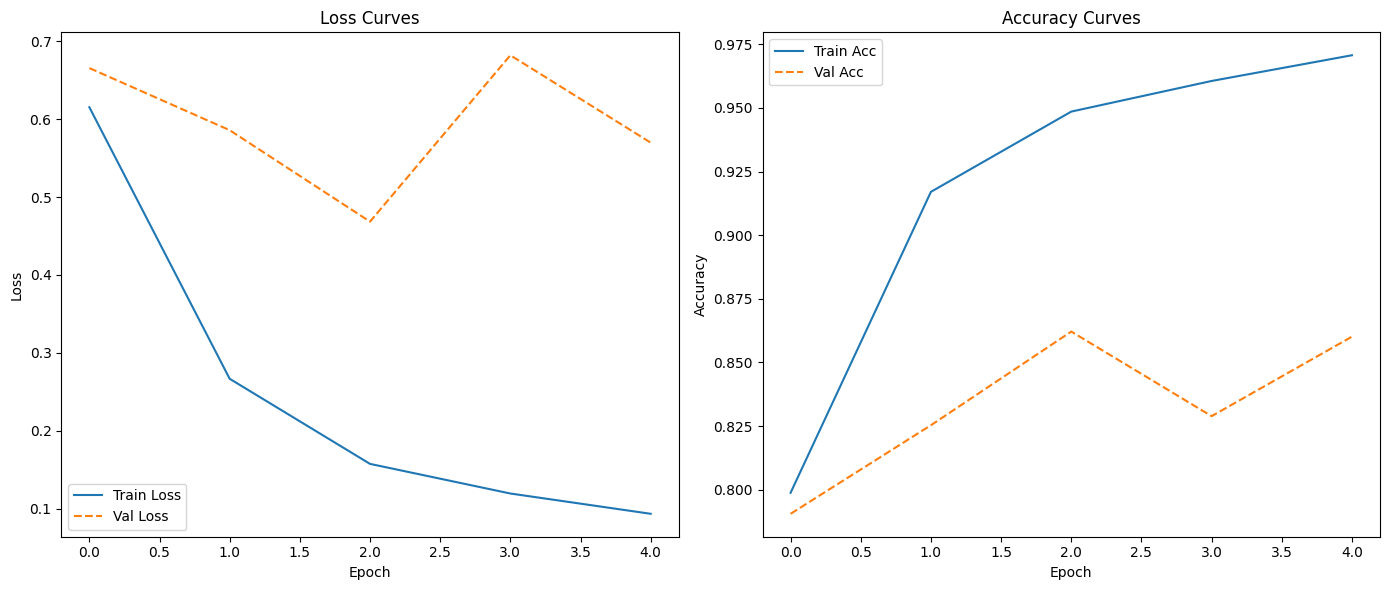

{'models': {4: WrapperModel(
    (model): VGG(
      (features): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (6): ReLU(inplace=True)
        (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (8): ReLU(inplace=True)
        (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (11): ReLU(inplace=True)
        (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (13): ReLU(inplace=True)
        (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), paddi

In [5]:
# Step 5: Run PretrainingPipeline Directly
pretraining_pipeline.run_pipeline()

-----
## Try ResNet50

In [6]:
# Step 3: Create SystemConfig for PretrainingPipeline Only
def create_notebook_config():
    
    """Create configuration optimized for notebook pretraining"""
    def get_device():
        if torch.cuda.is_available():
            return "cuda"
        elif torch.backends.mps.is_available():
            return "mps"
        else:
            return "cpu"

    config = SystemConfig(
        # Project settings
        project_name="notebook_pretraining",
        experiment_name="pretraining_experiment",

        device = get_device(),
        # Data paths
        train_data_path="./data_split/train-meta.csv",
        val_data_path="./data_split/val-meta.csv", 
        test_data_path="./data_split/test-meta.csv",

        # Preprocessed images path
        preprocessed_images_path= "../dataset/cct_resized/",

        # label mapping path
        label2idx_path = "./data_split/label_mapping.json",

        # models to use
        models_to_use = [3],
        
        # Training settings (notebook-friendly)
        batch_size=32,
        learning_rate=1e-4,
        weight_decay=0,
        patience = 0,
        epochs=5,  # Reduced for notebook

        # criterion
        criterion=nn.CrossEntropyLoss(),
        
        # Pipeline settings - ONLY PRETRAINING
        enable_pretraining_pipeline=True,
        enable_production_pipeline=False,  # Not needed

        # model training output dir
        training_output_dir="./pretrained_models",
        
        # Logging
        output_dir="./notebook_outputs",
        log_level="INFO",
        #console_logging=False,
        #include_full_file_paths=False  # Cleaner for notebook
        
    )
    
    
    
    return config

# Create configuration
config2=[]
config2 = create_notebook_config()
print("📝 Configuration created for notebook pretraining")
print(f"   - Device: {config.device}")
print(f"   - Output: {config.output_dir}")
print(f"   - Epochs: {config.epochs}")

📝 Configuration created for notebook pretraining
   - Device: mps
   - Output: ./notebook_outputs
   - Epochs: 5


In [7]:
# Step 4: Initialize PretrainingPipeline Directly
# Create the pipeline instance WITHOUT MasterMLSystem
pretraining_pipeline2 = []
pretraining_pipeline2 = PretrainingPipeline(config2)

print("🔬 PretrainingPipeline initialized successfully!")

🔬 PretrainingPipeline initialized successfully!


2025-08-05 03:21:22,792 - INFO - wildscan_ml_system.py:321 - run_pipeline() - 🔬 Starting Pretraining Pipeline...
2025-08-05 03:21:22,794 - INFO - wildscan_ml_system.py:185 - setup_datasets() - Setting up datasets for pretraining...
2025-08-05 03:21:22,794 - DEBUG - custom_datasets.py:56 - __init__() - input local csv: ./data_split/train-meta.csv
2025-08-05 03:21:22,868 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (19697, 15)
2025-08-05 03:21:22,869 - DEBUG - custom_datasets.py:84 - __init__() - no need to initialize s3fs since using local directory for dataset
2025-08-05 03:21:22,869 - INFO - custom_datasets.py:124 - __init__() - Loading label2idx mapping from local file: ./data_split/label_mapping.json
2025-08-05 03:21:22,869 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with 19697 samples.
2025-08-05 03:21:22,870 - DEBUG - custom_datasets.py:56 - __init__() - input local csv: ./data_split/val-meta.csv
2025-08-05 03:21:22,881 - INFO - custom_datase

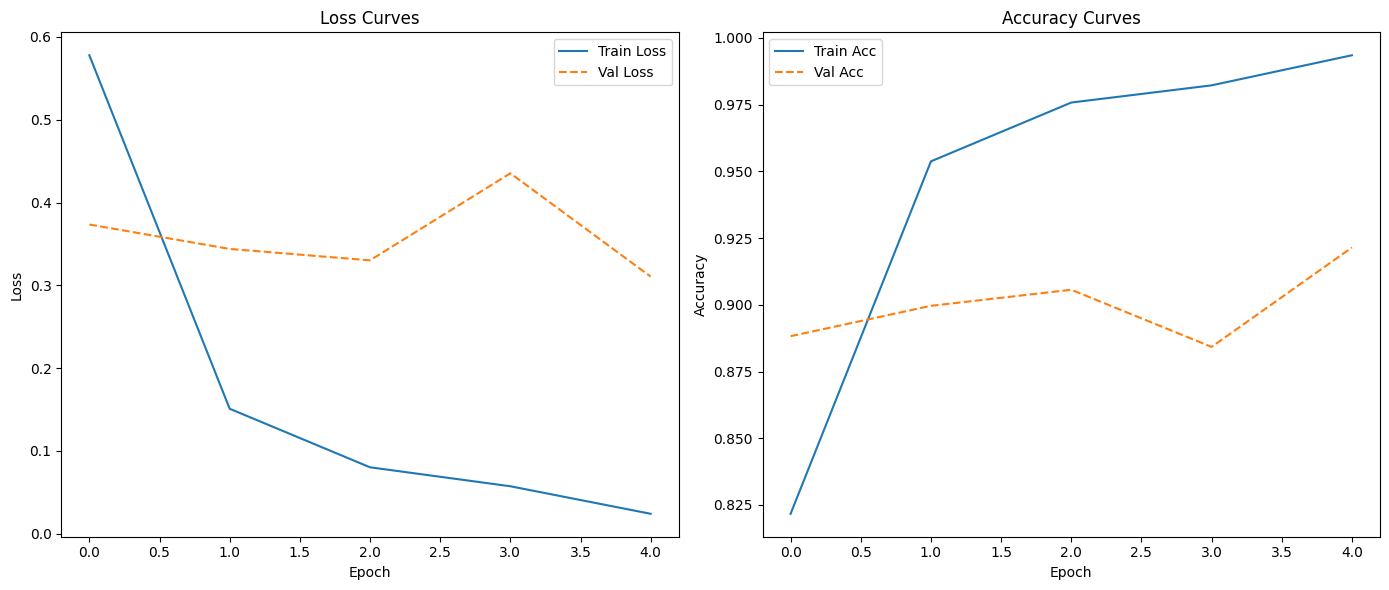

{'models': {3: WrapperModel(
    (model): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True

In [15]:
# Step 5: Run PretrainingPipeline Directly
pretraining_pipeline2.run_pipeline()

In [14]:
pretraining_pipeline.models[4]

WrapperModel(
  (model): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (

In [ ]:
import evaluator
importlib.reload(evaluator)
from evaluator import WildScanEvaluator as Evaluator
label2idx = pd.read_json(config.label2idx_path, typ='series')
label2idx

In [ ]:
# pass all models and dataset to WildScanEvaluator
premodels = pretraining_pipeline.models
premodels[1]

evaluator = Evaluator(premodels[1], device='mps',
                      test_loader=pretraining_pipeline.dataloaders['test'],
                      label_mapping=label2idx,)

In [ ]:
evaluator.evaluate()

In [ ]:
premodels[2]

evaluator2 = Evaluator(premodels[1], device='mps',
                      test_loader=pretraining_pipeline.dataloaders['test'],
                      label_mapping=label2idx,)
evaluator2.evaluate()